# Disney Animal Kingdom Wait Time & Guest Experience Analytics

This notebook is part of my Disney Animal Kingdom Wait Time & Guest Experience Analytics portfolio project. The purpose of this analysis is to evaluate attraction wait-time patterns, posted versus actual wait-time accuracy, and guest experience risk across Animal Kingdom attractions.

The analysis uses attraction-level wait-time CSV files from the TouringPlans Disney Animal Kingdom wait-time dataset. Each raw file represents a different attraction. These files are combined into one analysis-ready dataset so wait-time patterns can be compared across attractions, dates, and times of day.

## 1. Load Libraries and Upload Raw Data Files

In this section, I import the Python libraries needed for the analysis and upload the raw attraction-level CSV files. Each CSV file contains wait-time records for one Disney Animal Kingdom attraction.

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving AK01.csv to AK01.csv
Saving AK07.csv to AK07.csv
Saving AK11.csv to AK11.csv
Saving AK14.csv to AK14.csv
Saving AK17.csv to AK17.csv
Saving AK18.csv to AK18.csv
Saving AK20.csv to AK20.csv
Saving AK23.csv to AK23.csv
Saving AK25.csv to AK25.csv
Saving AK78.csv to AK78.csv
Saving AK85.csv to AK85.csv
Saving AK86.csv to AK86.csv


## 2. Combine Attraction-Level CSV Files

The raw dataset is split across multiple CSV files, with each file representing a different attraction. In this section, I combine the individual attraction files into one dataframe and add a source file column so each record can be traced back to its original CSV.

In [2]:
import io

all_dfs = []

for filename in uploaded.keys():
    temp_df = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Add source file name so we know which CSV each row came from
    temp_df["source_file"] = filename

    all_dfs.append(temp_df)

wait_times_raw = pd.concat(all_dfs, ignore_index=True)

wait_times_raw.head()

,date,datetime,SPOSTMIN,SACTMIN,source_file
0,01/01/2012,2012-01-01 10:28:00,0.0,NaN,AK01.csv
1,01/01/2012,2012-01-01 11:48:00,5.0,NaN,AK01.csv
2,01/01/2012,2012-01-01 14:21:00,5.0,NaN,AK01.csv
3,01/01/2012,2012-01-01 16:40:00,5.0,NaN,AK01.csv
4,01/01/2012,2012-01-01 17:39:00,0.0,NaN,AK01.csv


In [3]:
wait_times_raw.shape

(1905495, 5)

In [4]:
wait_times_raw.columns.tolist()

['date', 'datetime', 'SPOSTMIN', 'SACTMIN', 'source_file']

### Initial Load Summary

The raw attraction-level CSV files were successfully combined into one dataframe with 1,905,495 rows and 5 columns. The combined dataset includes the original date and datetime fields, posted wait time (`SPOSTMIN`), actual wait time (`SACTMIN`), and the source file name for each attraction.

The `source_file` column will be used to map each record to a readable attraction name.

## 3. Add Attraction Names

The original CSV files use file codes such as `AK01.csv`, `AK07.csv`, and `AK86.csv`. To make the analysis easier to understand, I map each file code to a readable attraction name.

In [5]:
attraction_map = {
    "AK01.csv": "Kilimanjaro Safaris",
    "AK07.csv": "DINOSAUR",
    "AK11.csv": "Expedition Everest",
    "AK14.csv": "Kali River Rapids",
    "AK18.csv": "Primeval Whirl",
    "AK85.csv": "Na'vi River Journey",
    "AK86.csv": "Avatar Flight of Passage"
}

wait_times_raw["attraction_name"] = wait_times_raw["source_file"].map(attraction_map)

wait_times_raw[["source_file", "attraction_name"]].drop_duplicates()

,source_file,attraction_name
0,AK01.csv,Kilimanjaro Safaris
220342,AK07.csv,DINOSAUR
450258,AK11.csv,Expedition Everest
693952,AK14.csv,Kali River Rapids
894573,AK17.csv,NaN
915300,AK18.csv,Primeval Whirl
1137797,AK20.csv,NaN
1363788,AK23.csv,NaN
1568800,AK25.csv,NaN
1572824,AK78.csv,NaN


In [6]:
attraction_map = {
    "AK01.csv": "Kilimanjaro Safaris",
    "AK07.csv": "DINOSAUR",
    "AK11.csv": "Expedition Everest",
    "AK14.csv": "Kali River Rapids",
    "AK17.csv": "TriceraTop Spin",
    "AK18.csv": "Primeval Whirl",
    "AK20.csv": "It's Tough to Be a Bug",
    "AK23.csv": "Festival of the Lion King",
    "AK25.csv": "Finding Nemo - The Musical",
    "AK78.csv": "Adventurers Outpost",
    "AK85.csv": "Na'vi River Journey",
    "AK86.csv": "Avatar Flight of Passage"
}

wait_times_raw["attraction_name"] = wait_times_raw["source_file"].map(attraction_map)

wait_times_raw[["source_file", "attraction_name"]].drop_duplicates()

,source_file,attraction_name
0,AK01.csv,Kilimanjaro Safaris
220342,AK07.csv,DINOSAUR
450258,AK11.csv,Expedition Everest
693952,AK14.csv,Kali River Rapids
894573,AK17.csv,TriceraTop Spin
915300,AK18.csv,Primeval Whirl
1137797,AK20.csv,It's Tough to Be a Bug
1363788,AK23.csv,Festival of the Lion King
1568800,AK25.csv,Finding Nemo - The Musical
1572824,AK78.csv,Adventurers Outpost


### Attraction Name Mapping Summary

The source files use attraction codes rather than readable attraction names. I created an attraction mapping dictionary to convert each source file into a business-friendly attraction name. This makes the dataset easier to analyze and improves the readability of future charts, tables, and dashboard views.

In [7]:
wait_times_raw["attraction_name"].isnull().sum()

np.int64(0)

In [8]:
# Check column names and data types

wait_times_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1905495 entries, 0 to 1905494
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   date             object 
 1   datetime         object 
 2   SPOSTMIN         float64
 3   SACTMIN          float64
 4   source_file      object 
 5   attraction_name  object 
dtypes: float64(2), object(4)
memory usage: 87.2+ MB


In [9]:
# Check missing values

wait_times_raw.isnull().sum()

,0
date,0
datetime,0
SPOSTMIN,26660
SACTMIN,1878835
source_file,0
attraction_name,0


In [10]:
# Check how many records came from each attraction

wait_times_raw["attraction_name"].value_counts()

,count
attraction_name,
Expedition Everest,243694
DINOSAUR,229916
It's Tough to Be a Bug,225991
Primeval Whirl,222497
Kilimanjaro Safaris,220342
Festival of the Lion King,205012
Kali River Rapids,200621
Adventurers Outpost,165979
Avatar Flight of Passage,83674


In [11]:
# Preview summary statistics for posted and actual wait times

wait_times_raw[["SPOSTMIN", "SACTMIN"]].describe()

,SPOSTMIN,SACTMIN
count,1.878835e+06,26660.000000
mean,-3.533646e+01,23.219580
std,2.540717e+02,296.117235
min,-9.990000e+02,0.000000
25%,1.000000e+01,6.000000
50%,1.500000e+01,13.000000
75%,4.000000e+01,26.000000
max,3.900000e+02,47897.000000


### Initial Data Inspection Summary

The combined dataset contains 1,905,495 records across 12 Animal Kingdom attraction files. The attraction name mapping was successful, with no missing values in the `attraction_name` field.

The dataset includes both posted wait times (`SPOSTMIN`) and actual wait times (`SACTMIN`). Posted wait times are available for most records, while actual wait times are only available for a smaller subset of the data. Because of this, the main analysis will focus primarily on posted wait-time patterns, while actual wait times will be used separately for posted-versus-actual wait-time accuracy where valid data is available.

The posted wait-time field includes invalid values such as `-999`, which indicates that an attraction was likely offline or unavailable. These records will need to be flagged or removed before calculating standard wait-time KPIs.

## 5. Data Cleaning Preparation

In this section, I create a cleaned version of the combined wait-time dataset. The cleaning process includes standardizing column names, converting date and time fields, flagging attraction closures, removing invalid wait-time values from analysis fields, and preparing the dataset for guest experience and operations analysis.

In [12]:
# Create a copy of the raw combined dataset for cleaning

wait_times_cleaned = wait_times_raw.copy()

wait_times_cleaned.head()

,date,datetime,SPOSTMIN,SACTMIN,source_file,attraction_name
0,01/01/2012,2012-01-01 10:28:00,0.0,NaN,AK01.csv,Kilimanjaro Safaris
1,01/01/2012,2012-01-01 11:48:00,5.0,NaN,AK01.csv,Kilimanjaro Safaris
2,01/01/2012,2012-01-01 14:21:00,5.0,NaN,AK01.csv,Kilimanjaro Safaris
3,01/01/2012,2012-01-01 16:40:00,5.0,NaN,AK01.csv,Kilimanjaro Safaris
4,01/01/2012,2012-01-01 17:39:00,0.0,NaN,AK01.csv,Kilimanjaro Safaris


### 5.1 Standardize Column Names

The original dataset contains abbreviated column names such as `SPOSTMIN` and `SACTMIN`. In this step, I rename the columns to make the dataset easier to understand and use in later analysis.

In [13]:
# Rename columns for readability

wait_times_cleaned = wait_times_cleaned.rename(columns={
    "SPOSTMIN": "posted_wait_minutes",
    "SACTMIN": "actual_wait_minutes"
})

wait_times_cleaned.columns.tolist()

['date',
 'datetime',
 'posted_wait_minutes',
 'actual_wait_minutes',
 'source_file',
 'attraction_name']

### 5.2 Convert Date and Time Fields

The date and datetime columns are converted into proper datetime formats. This allows the analysis to examine wait-time patterns by year, month, day of week, and hour of day.

In [14]:
# Convert date and datetime fields

wait_times_cleaned["date"] = pd.to_datetime(wait_times_cleaned["date"], errors="coerce")
wait_times_cleaned["datetime"] = pd.to_datetime(wait_times_cleaned["datetime"], errors="coerce")

wait_times_cleaned[["date", "datetime"]].dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]


### 5.3 Flag Attraction Closures and Invalid Wait Times

The dataset uses `-999` to represent times when an attraction was unavailable or unexpectedly offline. Because `-999` is not a real wait time, I create closure flags and replace those invalid wait-time values with missing values for analysis.

In [15]:
import numpy as np

# Create flags for invalid/offline posted and actual wait-time records
wait_times_cleaned["posted_wait_invalid"] = wait_times_cleaned["posted_wait_minutes"] == -999
wait_times_cleaned["actual_wait_invalid"] = wait_times_cleaned["actual_wait_minutes"] == -999

# Replace invalid wait-time values with NaN for analysis
wait_times_cleaned["posted_wait_minutes_clean"] = wait_times_cleaned["posted_wait_minutes"].replace(-999, np.nan)
wait_times_cleaned["actual_wait_minutes_clean"] = wait_times_cleaned["actual_wait_minutes"].replace(-999, np.nan)

# Check invalid value counts
wait_times_cleaned[["posted_wait_invalid", "actual_wait_invalid"]].sum()

,0
posted_wait_invalid,120179
actual_wait_invalid,0


In [16]:
wait_times_cleaned[[
    "posted_wait_minutes",
    "posted_wait_minutes_clean",
    "actual_wait_minutes",
    "actual_wait_minutes_clean",
    "posted_wait_invalid",
    "actual_wait_invalid"
]].head()

,posted_wait_minutes,posted_wait_minutes_clean,actual_wait_minutes,actual_wait_minutes_clean,posted_wait_invalid,actual_wait_invalid
0,0.0,0.0,NaN,NaN,False,False
1,5.0,5.0,NaN,NaN,False,False
2,5.0,5.0,NaN,NaN,False,False
3,5.0,5.0,NaN,NaN,False,False
4,0.0,0.0,NaN,NaN,False,False


In [17]:
# Count invalid/offline wait-time records

wait_times_cleaned[["posted_wait_invalid", "actual_wait_invalid"]].sum()

,0
posted_wait_invalid,120179
actual_wait_invalid,0


### Invalid Wait-Time Cleaning Summary

The dataset includes 120,179 posted wait-time records coded as `-999`, which represents attraction downtime or unavailable wait-time information rather than a true guest wait time.

These invalid posted wait-time values were flagged using the `posted_wait_invalid` field and replaced with missing values in `posted_wait_minutes_clean`. The cleaned posted wait-time field will be used for standard wait-time analysis so that attraction closures do not distort average wait-time calculations.

No invalid `-999` values were found in the actual wait-time field.

### 5.4 Create Time-Based Fields

To support time-based guest experience analysis, I create fields for year, month, day of week, and hour of day. These fields will allow wait-time patterns to be analyzed by season, weekday, and time of day.

In [18]:
# Create time-based fields

wait_times_cleaned["year"] = wait_times_cleaned["datetime"].dt.year
wait_times_cleaned["month"] = wait_times_cleaned["datetime"].dt.month
wait_times_cleaned["month_name"] = wait_times_cleaned["datetime"].dt.month_name()
wait_times_cleaned["day_of_week"] = wait_times_cleaned["datetime"].dt.day_name()
wait_times_cleaned["hour_of_day"] = wait_times_cleaned["datetime"].dt.hour
wait_times_cleaned["date_only"] = wait_times_cleaned["datetime"].dt.date

wait_times_cleaned[[
    "datetime",
    "year",
    "month",
    "month_name",
    "day_of_week",
    "hour_of_day",
    "date_only"
]].head()

,datetime,year,month,month_name,day_of_week,hour_of_day,date_only
0,2012-01-01 10:28:00,2012,1,January,Sunday,10,2012-01-01
1,2012-01-01 11:48:00,2012,1,January,Sunday,11,2012-01-01
2,2012-01-01 14:21:00,2012,1,January,Sunday,14,2012-01-01
3,2012-01-01 16:40:00,2012,1,January,Sunday,16,2012-01-01
4,2012-01-01 17:39:00,2012,1,January,Sunday,17,2012-01-01


### 5.5 Create Guest Experience KPI Fields

In this step, I create guest experience KPI fields that will support the main analysis. These fields include the posted-versus-actual wait-time gap, high-wait indicators, and wait-time categories. These fields help translate raw wait-time records into business-friendly measures of attraction demand and guest experience risk.

In [19]:
# Create wait-time gap field where actual wait data is available

wait_times_cleaned["wait_time_gap"] = (
    wait_times_cleaned["actual_wait_minutes_clean"] -
    wait_times_cleaned["posted_wait_minutes_clean"]
)

# Create high-wait flag based on posted wait time
wait_times_cleaned["is_high_wait"] = np.where(
    wait_times_cleaned["posted_wait_minutes_clean"] >= 45,
    1,
    0
)

# Create wait-time category field
wait_times_cleaned["wait_time_category"] = pd.cut(
    wait_times_cleaned["posted_wait_minutes_clean"],
    bins=[-1, 15, 30, 45, 60, float("inf")],
    labels=["0-15 min", "16-30 min", "31-45 min", "46-60 min", "60+ min"]
)

wait_times_cleaned[[
    "attraction_name",
    "posted_wait_minutes_clean",
    "actual_wait_minutes_clean",
    "wait_time_gap",
    "is_high_wait",
    "wait_time_category"
]].head()

,attraction_name,posted_wait_minutes_clean,actual_wait_minutes_clean,wait_time_gap,is_high_wait,wait_time_category
0,Kilimanjaro Safaris,0.0,NaN,NaN,0,0-15 min
1,Kilimanjaro Safaris,5.0,NaN,NaN,0,0-15 min
2,Kilimanjaro Safaris,5.0,NaN,NaN,0,0-15 min
3,Kilimanjaro Safaris,5.0,NaN,NaN,0,0-15 min
4,Kilimanjaro Safaris,0.0,NaN,NaN,0,0-15 min


In [20]:
wait_times_cleaned["wait_time_category"].value_counts(dropna=False)

,count
wait_time_category,
0-15 min,824488
16-30 min,408604
60+ min,214402
31-45 min,188918
NaN,146839
46-60 min,122244


### Guest Experience KPI Field Summary

The wait-time category field groups posted wait times into business-friendly ranges. Most valid wait-time records fall within the `0-15 min` and `16-30 min` categories, while a smaller but important share of records fall into the `60+ min` category.

The missing category values represent records where a valid posted wait time was not available, including invalid or offline records. These records will be excluded from standard posted wait-time analysis but may still be useful for understanding attraction downtime or unavailable wait-time information.

In [21]:
# Confirm final cleaned columns

wait_times_cleaned.columns.tolist()

['date',
 'datetime',
 'posted_wait_minutes',
 'actual_wait_minutes',
 'source_file',
 'attraction_name',
 'posted_wait_invalid',
 'actual_wait_invalid',
 'posted_wait_minutes_clean',
 'actual_wait_minutes_clean',
 'year',
 'month',
 'month_name',
 'day_of_week',
 'hour_of_day',
 'date_only',
 'wait_time_gap',
 'is_high_wait',
 'wait_time_category']

In [22]:
# Check cleaned dataset dimensions

wait_times_cleaned.shape

(1905495, 19)

### Cleaned Dataset Summary

The cleaned dataset contains 1,905,495 wait-time records and 19 columns. New fields were created to support guest experience and operations analysis, including cleaned posted and actual wait-time fields, invalid wait-time flags, time-based fields, wait-time gap, high-wait indicator, and wait-time category.

The cleaned dataset is now ready for attraction-level, time-based, and posted-versus-actual wait-time analysis.

## 6. Wait-Time Performance Analysis

This section analyzes posted wait-time patterns across Disney Animal Kingdom attractions. The goal is to identify which attractions have the highest average waits, highest peak waits, and greatest share of high-wait records.

### 6.1 Attraction Wait-Time Summary

This table summarizes posted wait-time performance by attraction, including total records, average posted wait time, median posted wait time, maximum posted wait time, and the percentage of records with waits of 45 minutes or more.

In [23]:
# Attraction-level posted wait-time summary

attraction_wait_summary = (
    wait_times_cleaned
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("attraction_name")
    .agg(
        total_records=("posted_wait_minutes_clean", "count"),
        avg_posted_wait=("posted_wait_minutes_clean", "mean"),
        median_posted_wait=("posted_wait_minutes_clean", "median"),
        max_posted_wait=("posted_wait_minutes_clean", "max"),
        high_wait_rate=("is_high_wait", "mean")
    )
    .reset_index()
)

# Round values for readability
attraction_wait_summary["avg_posted_wait"] = attraction_wait_summary["avg_posted_wait"].round(2)
attraction_wait_summary["median_posted_wait"] = attraction_wait_summary["median_posted_wait"].round(2)
attraction_wait_summary["high_wait_rate_pct"] = (attraction_wait_summary["high_wait_rate"] * 100).round(2)

# Remove helper decimal column
attraction_wait_summary = attraction_wait_summary.drop(columns=["high_wait_rate"])

# Sort by average posted wait time
attraction_wait_summary.sort_values("avg_posted_wait", ascending=False)

,attraction_name,total_records,avg_posted_wait,median_posted_wait,max_posted_wait,high_wait_rate_pct
1,Avatar Flight of Passage,78581,136.03,130.0,390.0,99.20
9,Na'vi River Journey,76758,75.29,75.0,225.0,85.11
2,DINOSAUR,217285,34.81,30.0,195.0,33.55
7,Kali River Rapids,183719,33.50,30.0,210.0,30.37
3,Expedition Everest,224460,31.03,30.0,180.0,25.35
10,Primeval Whirl,204465,24.86,20.0,300.0,15.32
0,Adventurers Outpost,147933,23.84,20.0,205.0,10.00
6,It's Tough to Be a Bug,214691,19.89,20.0,120.0,5.82
5,Finding Nemo - The Musical,2921,18.37,15.0,100.0,6.57
8,Kilimanjaro Safaris,213522,9.77,10.0,160.0,0.53


### Interpretation

The attraction-level wait-time summary shows that Avatar Flight of Passage had the highest average posted wait time by a wide margin, with an average posted wait of 136.03 minutes and a median posted wait of 130 minutes. It also had a high-wait rate of 99.20%, meaning nearly all valid posted wait-time records were 45 minutes or higher.

Na'vi River Journey also stood out as a major wait-time pressure point, with an average posted wait of 75.29 minutes and a high-wait rate of 85.11%.

After these two attractions, average posted waits dropped substantially. DINOSAUR, Kali River Rapids, and Expedition Everest had average posted waits around 31 to 35 minutes. This suggests that Pandora attractions were the strongest drivers of guest wait-time pressure in the dataset.

### 6.2 Top Attractions by Average Posted Wait Time

This chart visualizes the attractions with the highest average posted wait times. The goal is to identify which attractions created the greatest wait-time pressure for guests.

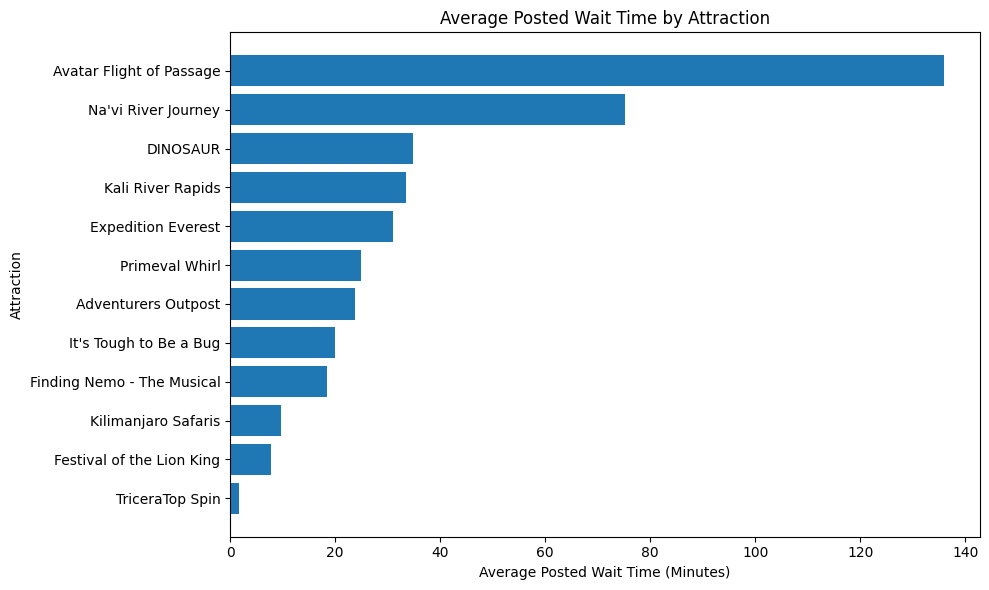

In [24]:
import matplotlib.pyplot as plt

# Sort attractions by average posted wait time
top_avg_wait = attraction_wait_summary.sort_values(
    "avg_posted_wait",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_avg_wait["attraction_name"], top_avg_wait["avg_posted_wait"])
plt.xlabel("Average Posted Wait Time (Minutes)")
plt.ylabel("Attraction")
plt.title("Average Posted Wait Time by Attraction")
plt.tight_layout()
plt.show()

### Interpretation

Avatar Flight of Passage had the highest average posted wait time by a wide margin, averaging about 136 minutes. Na'vi River Journey was the second-highest at about 75 minutes.

The gap between these two Pandora attractions and the rest of the park is substantial. After Na'vi River Journey, average posted waits drop to roughly 35 minutes or less. This suggests that Pandora attractions were the clearest wait-time pressure points in the dataset.

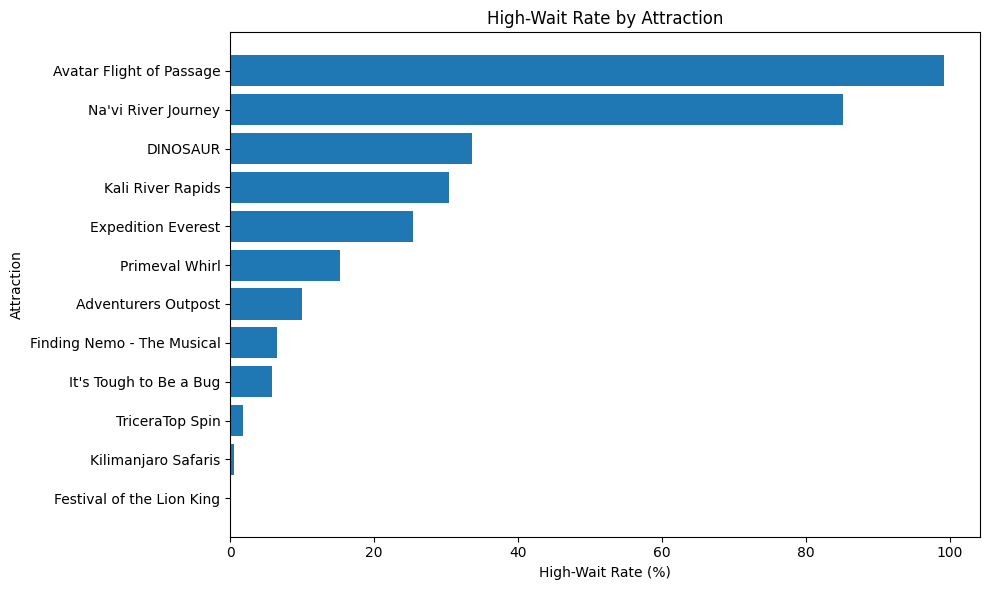

In [25]:
# Sort attractions by high-wait rate
high_wait_rate_chart = attraction_wait_summary.sort_values(
    "high_wait_rate_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    high_wait_rate_chart["attraction_name"],
    high_wait_rate_chart["high_wait_rate_pct"]
)

plt.xlabel("High-Wait Rate (%)")
plt.ylabel("Attraction")
plt.title("High-Wait Rate by Attraction")
plt.tight_layout()

# Save chart
plt.savefig("high_wait_rate_by_attraction.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

Avatar Flight of Passage and Na'vi River Journey had the highest high-wait rates in the dataset. Avatar Flight of Passage had posted waits of 45 minutes or more in nearly all valid wait-time records, while Na'vi River Journey also showed consistently high wait pressure.

This reinforces the finding that Pandora attractions were the strongest guest experience pressure points at Animal Kingdom. Other attractions, such as DINOSAUR, Kali River Rapids, and Expedition Everest, had moderate high-wait rates, while shows and lower-demand attractions had much lower rates.

## 7. Time-Based Wait-Time Patterns

This section analyzes how posted wait times change by hour of day, day of week, and month. The goal is to identify when wait-time pressure is highest and understand how guest experience risk changes across different time periods.

### 7.1 Average Posted Wait Time by Hour of Day

This chart shows how average posted wait times change throughout the day. This helps identify peak operating periods when guests are most likely to experience longer attraction waits.

In [26]:
# Average posted wait time by hour of day

hourly_wait_summary = (
    wait_times_cleaned
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("hour_of_day")
    .agg(
        avg_posted_wait=("posted_wait_minutes_clean", "mean"),
        total_records=("posted_wait_minutes_clean", "count")
    )
    .reset_index()
)

hourly_wait_summary["avg_posted_wait"] = hourly_wait_summary["avg_posted_wait"].round(2)

hourly_wait_summary

,hour_of_day,avg_posted_wait,total_records
0,0,38.43,924
1,1,20.38,120
2,2,8.48,56
3,3,7.50,24
4,6,17.31,444
5,7,16.99,11627
6,8,17.23,66288
7,9,21.01,147375
8,10,29.79,157263
9,11,35.71,157756


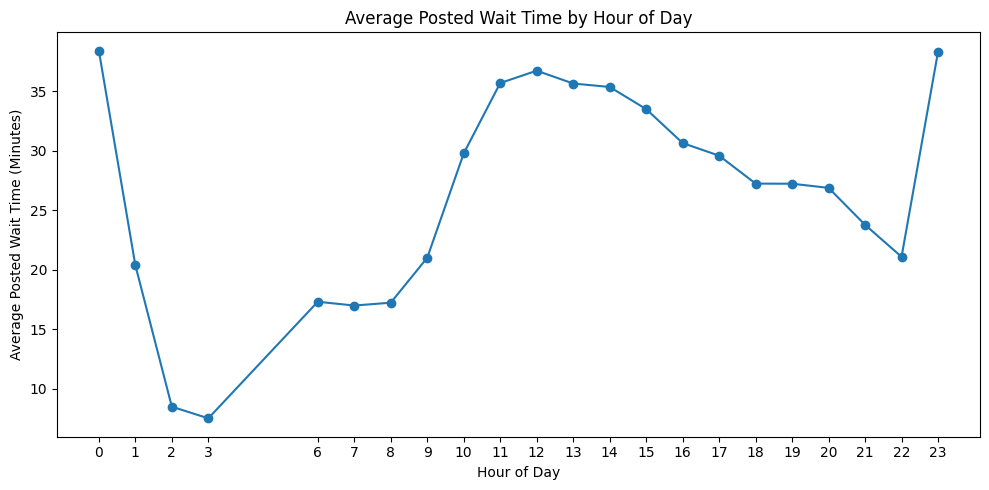

In [27]:
# Chart average posted wait time by hour of day

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_wait_summary["hour_of_day"],
    hourly_wait_summary["avg_posted_wait"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Posted Wait Time (Minutes)")
plt.title("Average Posted Wait Time by Hour of Day")
plt.xticks(hourly_wait_summary["hour_of_day"])
plt.tight_layout()

# Save chart
plt.savefig("average_posted_wait_time_by_hour.png", dpi=300, bbox_inches="tight")

plt.show()

### Operating-Hour Filter Note

The initial hourly wait-time chart included late-night and early-morning records that may represent unusual operating periods, special events, or sparse data. To make the time-of-day analysis more useful for standard guest experience insights, I filtered the chart to typical daytime operating hours.

In [28]:
# Filter to typical operating hours for a cleaner time-of-day analysis

operating_hours_waits = wait_times_cleaned[
    (wait_times_cleaned["hour_of_day"] >= 6) &
    (wait_times_cleaned["hour_of_day"] <= 22)
].copy()

hourly_wait_summary_filtered = (
    operating_hours_waits
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("hour_of_day")
    .agg(
        avg_posted_wait=("posted_wait_minutes_clean", "mean"),
        total_records=("posted_wait_minutes_clean", "count")
    )
    .reset_index()
)

hourly_wait_summary_filtered["avg_posted_wait"] = hourly_wait_summary_filtered["avg_posted_wait"].round(2)

hourly_wait_summary_filtered

,hour_of_day,avg_posted_wait,total_records
0,6,17.31,444
1,7,16.99,11627
2,8,17.23,66288
3,9,21.01,147375
4,10,29.79,157263
5,11,35.71,157756
6,12,36.75,157105
7,13,35.67,156281
8,14,35.38,156156
9,15,33.52,154510


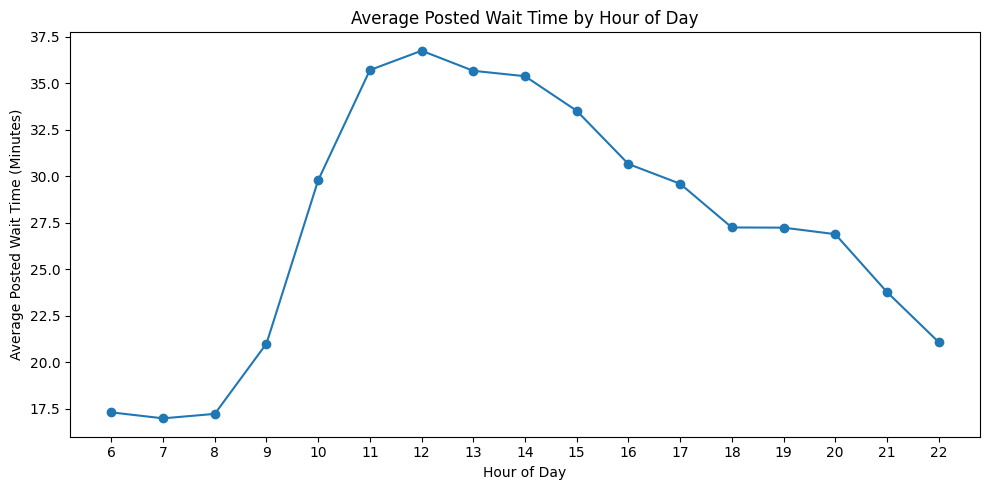

In [29]:
# Chart average posted wait time by hour of day during typical operating hours

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_wait_summary_filtered["hour_of_day"],
    hourly_wait_summary_filtered["avg_posted_wait"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Posted Wait Time (Minutes)")
plt.title("Average Posted Wait Time by Hour of Day")
plt.xticks(hourly_wait_summary_filtered["hour_of_day"])
plt.tight_layout()

# Save chart
plt.savefig("average_posted_wait_time_by_hour.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

Average posted wait times were lowest during the early operating hours, especially from 6 AM to 8 AM. Wait times increased sharply beginning around 9 AM and reached their highest point around 12 PM, with average posted waits of about 37 minutes.

After midday, average posted waits gradually declined throughout the afternoon and evening. This suggests that mid-morning through early afternoon was the highest-pressure period for guest wait times at Animal Kingdom.

### 7.2 Average Posted Wait Time by Day of Week

This chart shows how average posted wait times vary by day of week. The goal is to identify whether certain days tend to create higher wait-time pressure for guests.

In [30]:
# Average posted wait time by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_wait_summary = (
    wait_times_cleaned
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("day_of_week")
    .agg(
        avg_posted_wait=("posted_wait_minutes_clean", "mean"),
        total_records=("posted_wait_minutes_clean", "count")
    )
    .reset_index()
)

# Force days to appear in calendar order instead of alphabetical order
day_wait_summary["day_of_week"] = pd.Categorical(
    day_wait_summary["day_of_week"],
    categories=day_order,
    ordered=True
)

day_wait_summary = day_wait_summary.sort_values("day_of_week")

day_wait_summary["avg_posted_wait"] = day_wait_summary["avg_posted_wait"].round(2)

day_wait_summary

,day_of_week,avg_posted_wait,total_records
1,Monday,31.47,258898
5,Tuesday,30.43,245373
6,Wednesday,28.55,246506
4,Thursday,30.31,242138
0,Friday,30.61,244933
2,Saturday,31.82,263702
3,Sunday,30.28,257106


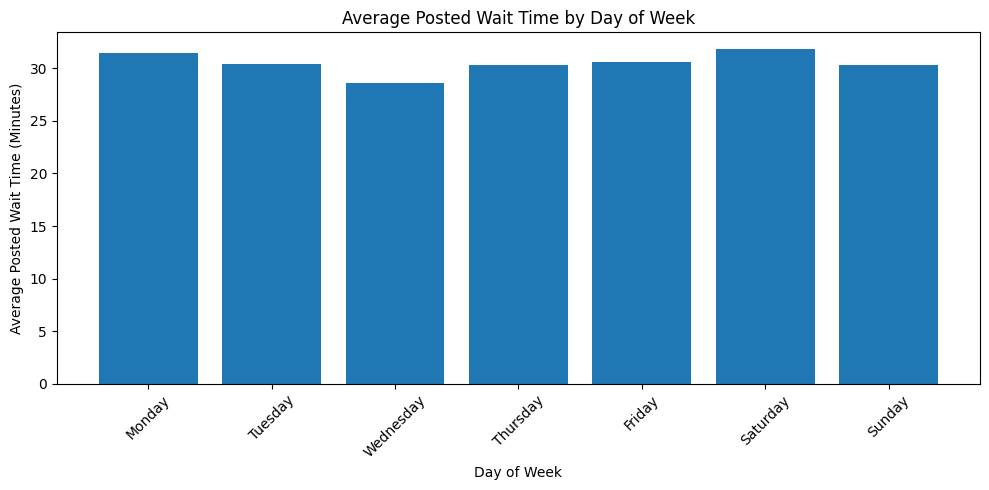

In [31]:
# Chart average posted wait time by day of week

plt.figure(figsize=(10, 5))
plt.bar(
    day_wait_summary["day_of_week"].astype(str),
    day_wait_summary["avg_posted_wait"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Posted Wait Time (Minutes)")
plt.title("Average Posted Wait Time by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig("average_posted_wait_time_by_day_of_week.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

Average posted wait times were relatively consistent across the week, with most days falling around 29 to 32 minutes. Saturday and Monday had the highest average posted waits, while Wednesday had the lowest.

The small difference between days suggests that day of week was not as strong of a driver of wait-time pressure as attraction type or hour of day. Attraction-level demand and time-of-day patterns appear to explain larger differences in guest wait experience.

### 7.3 Average Posted Wait Time by Month

This chart below shows how average posted wait times vary by month. The goal is to identify seasonal wait-time patterns and understand whether certain months tend to create higher guest experience pressure.

In [32]:
# Average posted wait time by month

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_wait_summary = (
    wait_times_cleaned
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby(["month", "month_name"])
    .agg(
        avg_posted_wait=("posted_wait_minutes_clean", "mean"),
        total_records=("posted_wait_minutes_clean", "count")
    )
    .reset_index()
)

# Force months to appear in calendar order
monthly_wait_summary["month_name"] = pd.Categorical(
    monthly_wait_summary["month_name"],
    categories=month_order,
    ordered=True
)

monthly_wait_summary = monthly_wait_summary.sort_values("month")

monthly_wait_summary["avg_posted_wait"] = monthly_wait_summary["avg_posted_wait"].round(2)

monthly_wait_summary

,month,month_name,avg_posted_wait,total_records
0,1,January,33.11,137696
1,2,February,32.58,133897
2,3,March,31.76,135578
3,4,April,28.98,135099
4,5,May,27.95,142114
5,6,June,31.63,167959
6,7,July,31.73,159118
7,8,August,29.25,155469
8,9,September,22.19,139573
9,10,October,29.37,150650


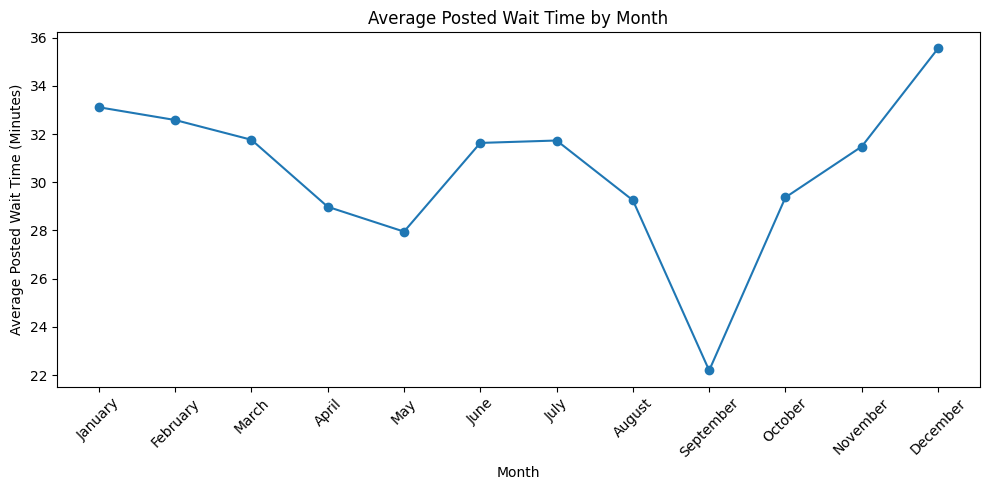

In [33]:
# Chart average posted wait time by month

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_wait_summary["month_name"].astype(str),
    monthly_wait_summary["avg_posted_wait"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Posted Wait Time (Minutes)")
plt.title("Average Posted Wait Time by Month")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig("average_posted_wait_time_by_month.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

Average posted wait times varied by month, suggesting a seasonal pattern in guest wait-time pressure. December had the highest average posted wait time, while September had the lowest.

Wait times were also relatively higher in January, February, June, July, and November. This pattern may reflect busier travel periods such as winter holidays, early-year travel, summer vacation, and the late-year holiday season.

September had a noticeably lower average posted wait time, suggesting it may have been one of the lower-pressure months for Animal Kingdom wait times in this dataset.

## 8. Posted vs. Actual Wait-Time Accuracy

This section compares posted wait times against actual wait times where valid actual wait-time data is available. The goal is to evaluate whether posted wait times tended to overestimate, underestimate, or accurately reflect the actual guest wait experience.

### 8.1 Posted vs. Actual Wait-Time Dataset

Actual wait-time records are only available for a smaller subset of the full dataset. In this step, I filter the data to records where both posted and actual wait times are available and valid.

In [34]:
# Create a subset where both posted and actual wait times are available

posted_actual_waits = wait_times_cleaned.dropna(
    subset=["posted_wait_minutes_clean", "actual_wait_minutes_clean"]
).copy()

posted_actual_waits.shape

(0, 19)

### Posted vs. Actual Wait-Time Availability Note

After filtering for records where both posted wait time and actual wait time were available in the same row, the resulting dataset contained 0 records. This means the attraction-level CSV files do not appear to support a direct row-level posted-versus-actual comparison in their current structure.

Because of this, the main analysis will focus on posted wait-time patterns, which are available for most records. Posted-versus-actual wait-time accuracy may be explored later using a separate matched dataset, such as the `master_act_vs_posted.xlsx` file if it contains paired posted and actual wait-time records.

In [35]:
# Inspect records where actual wait time is available

actual_wait_records = wait_times_cleaned.dropna(
    subset=["actual_wait_minutes_clean"]
).copy()

actual_wait_records.shape

(26660, 19)

In [36]:
# Preview actual wait-time records

actual_wait_records[[
    "date",
    "datetime",
    "attraction_name",
    "posted_wait_minutes_clean",
    "actual_wait_minutes_clean"
]].head(10)

,date,datetime,attraction_name,posted_wait_minutes_clean,actual_wait_minutes_clean
9,2012-01-03,2012-01-03 14:36:00,Kilimanjaro Safaris,NaN,7.0
16,2012-01-06,2012-01-06 10:32:00,Kilimanjaro Safaris,NaN,7.0
35,2012-01-13,2012-01-13 13:37:00,Kilimanjaro Safaris,NaN,5.0
37,2012-01-14,2012-01-14 09:40:00,Kilimanjaro Safaris,NaN,10.0
38,2012-01-14,2012-01-14 10:52:00,Kilimanjaro Safaris,NaN,11.0
45,2012-01-17,2012-01-17 11:20:00,Kilimanjaro Safaris,NaN,11.0
52,2012-01-20,2012-01-20 11:25:00,Kilimanjaro Safaris,NaN,10.0
63,2012-01-25,2012-01-25 09:50:00,Kilimanjaro Safaris,NaN,6.0
74,2012-01-28,2012-01-28 16:18:00,Kilimanjaro Safaris,NaN,5.0
77,2012-01-30,2012-01-30 10:17:00,Kilimanjaro Safaris,NaN,7.0


In [37]:
# Check which attractions have actual wait-time records

actual_wait_records["attraction_name"].value_counts()

,count
attraction_name,
Expedition Everest,6791
Primeval Whirl,5036
DINOSAUR,4884
It's Tough to Be a Bug,3253
Avatar Flight of Passage,1708
Na'vi River Journey,1604
Festival of the Lion King,1210
Kali River Rapids,1114
Kilimanjaro Safaris,770


### Actual Wait-Time Availability Summary

The dataset contains 26,660 records with actual wait-time values. However, these actual wait-time records do not appear to be paired with posted wait-time values in the same rows. Because of this, the attraction-level CSV files do not support a direct posted-versus-actual wait-time accuracy calculation in their current structure.

Actual wait-time records are available for several attractions, with the largest counts for Expedition Everest, Primeval Whirl, DINOSAUR, and It's Tough to Be a Bug. For the main project, the primary analysis will focus on posted wait-time patterns because posted waits are available for most records. Actual wait-time analysis may be explored separately as a limited subset or revisited later using a matched posted-versus-actual dataset.

## 8. Guest Experience Risk Analysis

This section uses the cleaned posted wait-time data to summarize guest experience risk. The goal is to identify attractions and time periods where guests were most likely to encounter long waits.

### 8.1 High-Wait Records by Attraction

This table below summarizes how often each attraction had posted waits of 45 minutes or more. This helps identify attractions that created recurring wait-time pressure, not just occasional long waits.

In [38]:
# High-wait records by attraction

high_wait_summary = (
    wait_times_cleaned
    .dropna(subset=["posted_wait_minutes_clean"])
    .groupby("attraction_name")
    .agg(
        total_valid_records=("posted_wait_minutes_clean", "count"),
        high_wait_records=("is_high_wait", "sum"),
        avg_posted_wait=("posted_wait_minutes_clean", "mean")
    )
    .reset_index()
)

high_wait_summary["high_wait_rate_pct"] = (
    high_wait_summary["high_wait_records"] / high_wait_summary["total_valid_records"] * 100
).round(2)

high_wait_summary["avg_posted_wait"] = high_wait_summary["avg_posted_wait"].round(2)

high_wait_summary.sort_values("high_wait_rate_pct", ascending=False)

,attraction_name,total_valid_records,high_wait_records,avg_posted_wait,high_wait_rate_pct
1,Avatar Flight of Passage,78581,77949,136.03,99.20
9,Na'vi River Journey,76758,65325,75.29,85.11
2,DINOSAUR,217285,72908,34.81,33.55
7,Kali River Rapids,183719,55798,33.50,30.37
3,Expedition Everest,224460,56892,31.03,25.35
10,Primeval Whirl,204465,31320,24.86,15.32
0,Adventurers Outpost,147933,14795,23.84,10.00
5,Finding Nemo - The Musical,2921,192,18.37,6.57
6,It's Tough to Be a Bug,214691,12491,19.89,5.82
11,TriceraTop Spin,718,13,1.73,1.81


### Interpretation

The high-wait summary shows that Avatar Flight of Passage and Na'vi River Journey were the strongest recurring wait-time pressure points in the dataset. Avatar Flight of Passage had 77,949 high-wait records, representing 99.20% of its valid posted wait-time records. Na'vi River Journey also showed elevated wait-time pressure, with 65,325 high-wait records and a high-wait rate of 85.11%.

After these two attractions, the high-wait rate drops substantially. DINOSAUR, Kali River Rapids, and Expedition Everest had moderate high-wait rates, while attractions such as Kilimanjaro Safaris and Festival of the Lion King rarely crossed the 45-minute high-wait threshold.

This suggests that guest experience risk was concentrated most heavily around a small number of high-demand attractions.

### 8.2 High-Wait Records by Attraction

This chart below shows the total number of high-wait records for each attraction. A high-wait record is defined as any valid posted wait-time record of 45 minutes or more.

While the high-wait rate shows how often an attraction crossed the high-wait threshold, the total number of high-wait records helps show the overall volume of guest experience pressure. This is useful because an attraction may have a high wait rate but a smaller number of total records, while another attraction may create a larger operational impact due to higher volume.

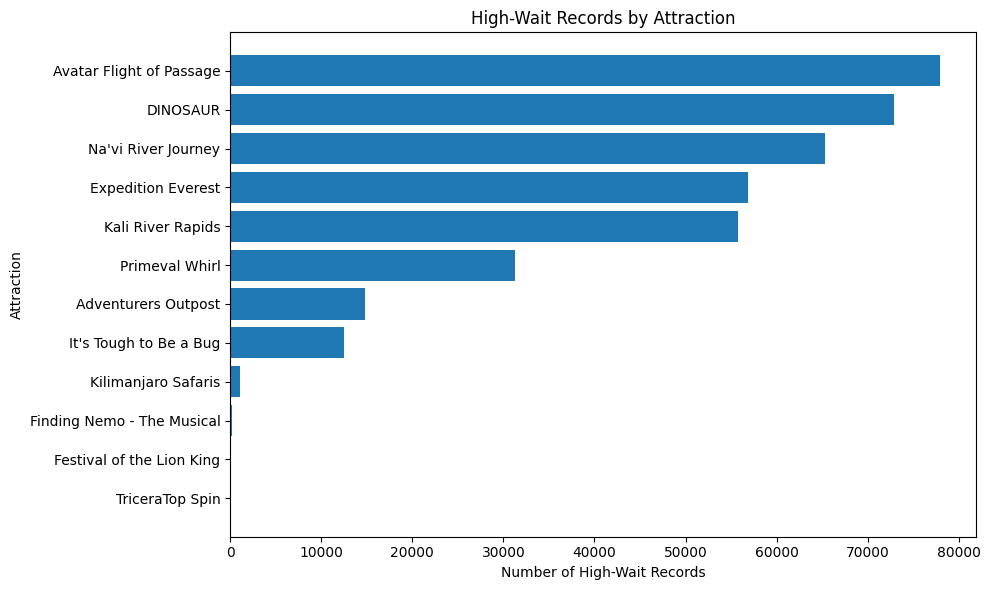

In [39]:
# Sort attractions by high-wait record count
high_wait_records_chart = high_wait_summary.sort_values(
    "high_wait_records",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    high_wait_records_chart["attraction_name"],
    high_wait_records_chart["high_wait_records"]
)

plt.xlabel("Number of High-Wait Records")
plt.ylabel("Attraction")
plt.title("High-Wait Records by Attraction")
plt.tight_layout()

# Save chart
plt.savefig("high_wait_records_by_attraction.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

Avatar Flight of Passage had the highest number of high-wait records, reinforcing its role as the largest guest experience pressure point in the dataset. DINOSAUR also had a very large number of high-wait records, even though its high-wait rate was lower than Avatar Flight of Passage and Na'vi River Journey. This suggests that DINOSAUR created meaningful operational pressure because of its large number of valid wait-time records.

Na'vi River Journey, Expedition Everest, and Kali River Rapids also contributed a substantial number of high-wait records. Together, this chart shows that guest experience risk was concentrated among a small group of high-demand attractions.

High-wait rate = how often an attraction had long waits
High-wait records = how many total long-wait observations appeared

## 9. Key Findings and Recommendations

This section summarizes the main findings from the Disney Animal Kingdom wait-time analysis. The goal is to translate the data analysis into clear guest experience and operational insights.

### 9.1 Key Findings

1. **Avatar Flight of Passage was the strongest wait-time pressure point.**  
   Avatar Flight of Passage had the highest average posted wait time at approximately 136 minutes. It also had a high-wait rate of 99.20%, meaning nearly every valid posted wait-time record was 45 minutes or longer.

2. **Na'vi River Journey was the second-largest wait-time pressure point.**  
   Na'vi River Journey had an average posted wait time of approximately 75 minutes and a high-wait rate of 85.11%. This reinforces that Pandora attractions created the most consistent wait-time pressure in the dataset.

3. **Wait-time pressure was concentrated in a small group of attractions.**  
   After Avatar Flight of Passage and Na'vi River Journey, average posted wait times dropped significantly. DINOSAUR, Kali River Rapids, and Expedition Everest showed moderate wait-time pressure, while several other attractions had much lower average waits.

4. **Midday was the highest-pressure time of day.**  
   Average posted wait times were lowest in the early morning and rose sharply beginning around 9 AM. Wait times peaked around noon before gradually declining through the afternoon and evening.

5. **Day of week was not a major driver of wait-time differences.**  
   Average posted wait times were fairly consistent across the week, with most days falling around 29 to 32 minutes. This suggests that attraction demand and time of day were stronger drivers than weekday alone.

6. **Seasonal patterns were visible by month.**  
   December had the highest average posted wait time, while September had the lowest. Higher waits in December, January, February, June, July, and November may reflect holiday and vacation travel periods.

### 9.2 Business Recommendations

1. **Prioritize crowd-flow and capacity strategies around Pandora attractions.**  
   Avatar Flight of Passage and Na'vi River Journey consistently showed the highest wait-time pressure. These attractions should be treated as primary guest experience risk areas when planning staffing, queue management, and guest communication.

2. **Use early-morning hours to encourage demand distribution.**  
   Since average wait times were lowest early in the day, guests could be encouraged to visit high-demand attractions earlier through app messaging, itinerary suggestions, or planning recommendations.

3. **Monitor midday operations closely.**  
   Wait times peaked around noon, making late morning through early afternoon the most important period for operational monitoring and guest experience support.

4. **Prepare for seasonal demand increases.**  
   December showed the highest average posted wait time, while other high-pressure months included January, February, June, July, and November. These months may require stronger operational planning and guest communication.

5. **Use high-wait rate and high-wait record counts together.**  
   High-wait rate shows how frequently an attraction has long waits, while high-wait record count shows total volume of long-wait observations. Using both metrics helps identify attractions that create recurring and high-volume guest experience pressure.

### 9.3 Project Summary

This analysis shows that wait-time pressure at Disney Animal Kingdom was not evenly distributed across attractions or time periods. The strongest guest experience risks were concentrated around Pandora attractions, especially Avatar Flight of Passage and Na'vi River Journey. Time of day also played an important role, with average posted wait times rising sharply in the morning and peaking around midday.

These findings suggest that attraction-level demand, hourly operating patterns, and seasonal travel periods are important factors for understanding guest wait-time experience and supporting operational planning.

## 10. Save Cleaned Dataset

In this section, I export the cleaned and analysis-ready dataset. This file can be reused for SQL analysis, Tableau dashboarding, and future predictive modeling.

Because the cleaned dataset may be too large for standard GitHub upload, the CSV file may be stored locally rather than included directly in the repository. The `data/processed/README.md` file explains how to recreate the cleaned dataset by running this notebook.

In [40]:
# Save cleaned dataset locally

wait_times_cleaned.to_csv(
    "animal_kingdom_wait_times_cleaned.csv",
    index=False
)

In [41]:
from google.colab import files

files.download("animal_kingdom_wait_times_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>